**Housing Price Analysis**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data
path=r"C:\Users\user\Documents\ALTschool\Project\Housing.csv"
df=pd.read_csv(path)

In [3]:
df.head

<bound method NDFrame.head of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no  

In [4]:
# print the shape 
df.shape

(545, 13)

In [5]:
# displaying the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# summary statistics for all numeric columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
#count of each unqiue categorical values
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())
    print()

mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
no     448
yes     97
Name: count, dtype: int64

basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64



In [8]:
#check for missing values
#where 0 is false and 1 is true

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
#checking for duplicates


df.duplicated().sum()

np.int64(0)

In [10]:
#outlier checking

q1_price=df['price'].quantile(0.25)
print(q1_price)


3430000.0


In [11]:
q3_price=df['price'].quantile(0.75)
print(q3_price)

5740000.0


In [12]:
iqr_price=q3_price-q1_price
upper_bound= q3_price+1.5*iqr_price
lower_bound= q1_price-1.5*iqr_price

In [13]:
price_outliers= df[(df['price'] > upper_bound) | (df['price'] < lower_bound)]
print(f'Number of outliers: {len(price_outliers)}')

Number of outliers: 15


In [14]:
q1_area=df['area'].quantile(0.25)
print(q1_area)

3600.0


In [15]:
q3_area=df['area'].quantile(0.75)
print(q3_area)

6360.0


In [16]:
iqr_area=q3_area-q1_area
upper_bound= q3_area+1.5*iqr_area
lower_bound= q1_area-1.5*iqr_area

In [17]:
area_outliers= df[(df['area'] > upper_bound) | (df['area'] < lower_bound)]
print(f'Number of outliers: {len(area_outliers)}')

Number of outliers: 12


In [18]:
#Verifing that categorical columns contains expected vales

categorical_columns = ['mainroad',
                       'guestroom',
                       'basement',
                       'hotwaterheating',
                       'airconditioning',
                       'prefarea',
                       'furnishingstatus'
                      ]

for col in categorical_columns:
    print(f"{col}:")
    print(df[col].value_counts())
    print()

mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

basement:
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64



**Analysis**

In [19]:
#Finding the average,median and max of house price
#Average
print(df['price'].mean())

4766729.247706422


In [20]:
#Median
print(df['price'].median())

4340000.0


In [21]:
#max
print(df['price'].max())

13300000


In [22]:
#correlation

correlation = df['area'].corr(df['price'])
print(f"The correlation = {correlation}, is a strong correlation" )

The correlation = 0.5359973457780801, is a strong correlation


In [23]:
#Top most expensive houses

top_5 = df.sort_values(by='price', ascending=False).head(5)
print(top_5)

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
1  12250000  8960         4          4        4      yes        no       no   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
2              no              no        2      yes   semi-furnished  
1              no             yes        3       no        furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [24]:
#comparing mainroad prices

average_prices = df.groupby('mainroad')['price'].mean()
print(average_prices)

mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64


In [25]:
#does airconditioning affect prices?

air_prices = df.groupby('airconditioning')['price'].mean()
print(air_prices)

airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64


In [26]:
#does furnishing status affect price?

furnish_prices = df.groupby('furnishingstatus')['price'].mean().sort_values(ascending=False)
print(furnish_prices)

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


In [27]:
#Most common number of bedroom?

print(df['bedrooms'].mode()[0])

3


In [28]:
print(df['bedrooms'].value_counts(normalize=True)[3]*100)

55.04587155963303


In [34]:
#How many houses have both basement and air conditioning

basement_air = df[(df['basement'] == 'yes') & (df['airconditioning'] == 'yes')]
print(len(basement_air))

66


In [35]:
#Average price of houses with basement and airconditioning
print(basement_air['price'].mean())

6081196.96969697


In [41]:
#relationship between stories and price

stories_pricesrelate = df['stories'].corr(df['price'])
print(stories_pricesrelate)

0.4207123661886166


*VISUALISATION*

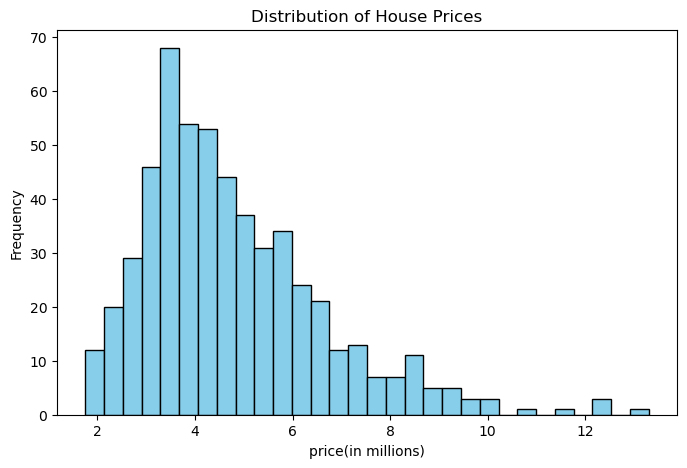

In [43]:
#Histogram for price distribution

plt.figure(figsize=(8,5))
plt.hist(df['price']/1_000_000, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('price(in millions)')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution. Most houses are priced between roughly 2 million to 6 million

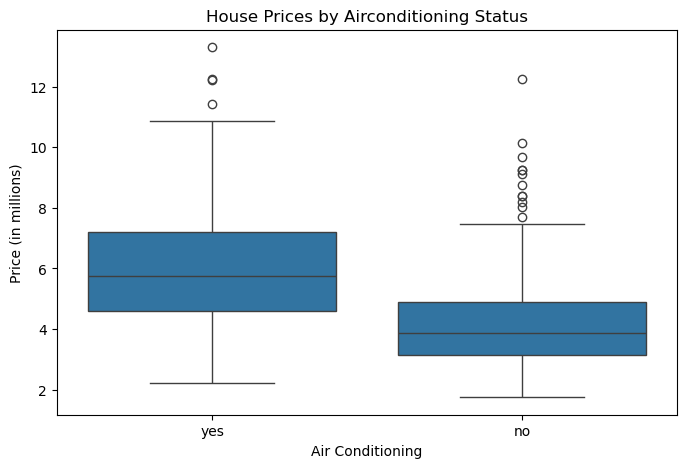

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='airconditioning', y=df['price']/1_000_000, data=df)

plt.title('House Prices by Airconditioning Status')
plt.xlabel('Air Conditioning')
plt.ylabel('Price (in millions)')
plt.show()

This box plot compares house prices for homes with and without airconditioning. 
Houses with air condition have higher median than the ones without, meaning that air conditioning is associated with more expensive properties

In [ ]:
average_bedprices = df.groupby('bedroom')['price'].mean()
plt.figure(figure=(8,5))
plt.bar(average_bedprices
